In [3]:
from sodapy import Socrata
import pandas as pd

client = Socrata("data.cityofnewyork.us", None)  # No app token needed for public data

# Fetch Beach Water Samples
beach_data = client.get("2xir-kwzz", limit=50000)
df_beach = pd.DataFrame.from_records(beach_data)

# Fetch Harbor Water Quality
harbor_data = client.get("5uug-f49n", limit=50000)
df_harbor = pd.DataFrame.from_records(harbor_data)

print(df_beach.head())
print(df_harbor.head())

          sample_id              sample_date  \
0  AC2609091000-1.2  2026-09-09T00:00:00.000   
1  AC2609091000-1.3  2026-09-09T00:00:00.000   
2  KB2609091005-1.2  2026-09-09T00:00:00.000   
3  AC2609090920-2.1  2026-09-09T00:00:00.000   
4  AC2609090830-1.1  2026-09-09T00:00:00.000   

                              beach_name sample_location enterococci_results  \
0        WEST FORDHAM STREET ASSOCIATION          Center                 9.9   
1        WEST FORDHAM STREET ASSOCIATION           Right                 9.9   
2        SCHUYLER HILL CIVIC ASSOCIATION          Center                 9.9   
3                          ORCHARD BEACH          Center                 9.9   
4  WHITESTONE BOOSTER CIVIC  ASSOCIATION            Left                 9.9   

  units_or_notes  
0     MPN/100 ml  
1     MPN/100 ml  
2     MPN/100 ml  
3     MPN/100 ml  
4     MPN/100 ml  
  sampling_location              sample_date sample_time  \
0               BB2  2006-08-09T00:00:00.000     1:53 PM

In [6]:
import sqlite3
from pathlib import Path
import pandas as pd

# Base folder path
DATA_DIR = Path(r"C:\Users\Dell\Downloads\Sustentability\Project2")

# Load
df = pd.read_csv(DATA_DIR / "beach_water_samples.csv")

# Standardize column headers
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# Dynamically map the enterococci column (e.g., 'enterococci_results' -> 'enterococci')
for col in df.columns:
    if "enterococci" in col and col != "enterococci":
        df.rename(columns={col: "enterococci"}, inplace=True)
        break

# Convert
df["sample_date"] = pd.to_datetime(df["sample_date"], errors="coerce")
df["enterococci"] = pd.to_numeric(df["enterococci"], errors="coerce")

# New columns
df["year"] = df["sample_date"].dt.year
df["month"] = df["sample_date"].dt.month
df["season"] = df["month"].map({
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
})
df["advisory"] = (df["enterococci"] > 104).astype(int)

# Drop nulls
df.dropna(subset=["enterococci", "sample_date"], inplace=True)

# Save cleaned CSV
df.to_csv(DATA_DIR / "cleaned_beach_water.csv", index=False)

# Load into SQLite
conn = sqlite3.connect(DATA_DIR / "nyc_water.db")
df.to_sql("beach_samples", conn, if_exists="replace", index=False)
conn.close()

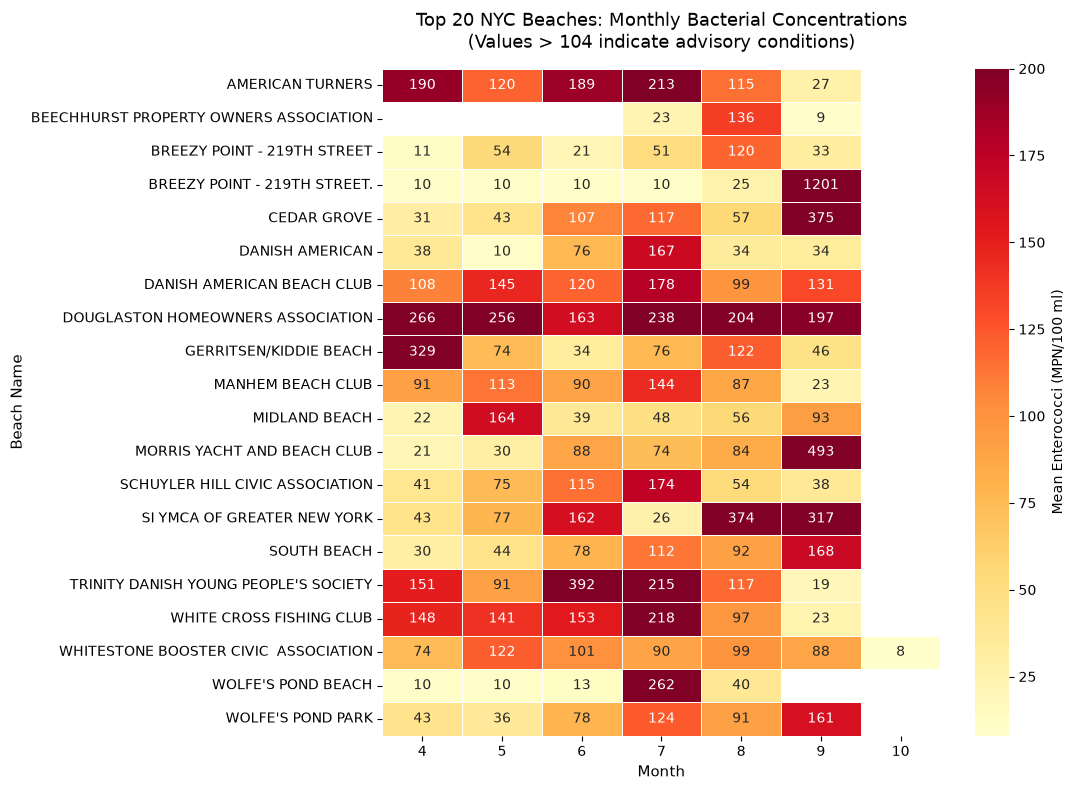

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the top 20 beaches with the highest overall average
top_beaches = (
    df.groupby("beach_name")["enterococci"]
    .mean()
    .nlargest(20)
    .index
)

# 2. Pivot table: Beach vs Month for top beaches
pivot_df = df[df["beach_name"].isin(top_beaches)].pivot_table(
    index="beach_name",
    columns="month",
    values="enterococci",
    aggfunc="mean",
)

# 3. Plot heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Enterococci (MPN/100 ml)"},
    vmax=200,  # Caps extreme outlier color scale to keep lower values visible
)

plt.title(
    "Top 20 NYC Beaches: Monthly Bacterial Concentrations\n(Values > 104 indicate advisory conditions)",
    fontsize=13,
    pad=15,
)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Beach Name", fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
%pip install plotly

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------------------------- -------------- 6.3/9.7 MB 34.6 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 32.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import folium
from folium.plugins import HeatMap
from IPython.display import display

# Center on NYC coastline using free OpenStreetMap tiles (no watermark)
nyc_map = folium.Map(
    location=[40.68, -73.95],
    zoom_start=11,
    tiles="OpenStreetMap"  # Replaces CartoDB to eliminate the API key watermark
)

# Build heat data [lat, lon, weight]
heat_data = [
    [row["latitude"], row["longitude"], min(row["enterococci"], 300)]
    for _, row in map_data.iterrows()
]

HeatMap(heat_data, radius=20, blur=14, max_zoom=13).add_to(nyc_map)

# Displays directly inside your notebook cell
display(nyc_map)

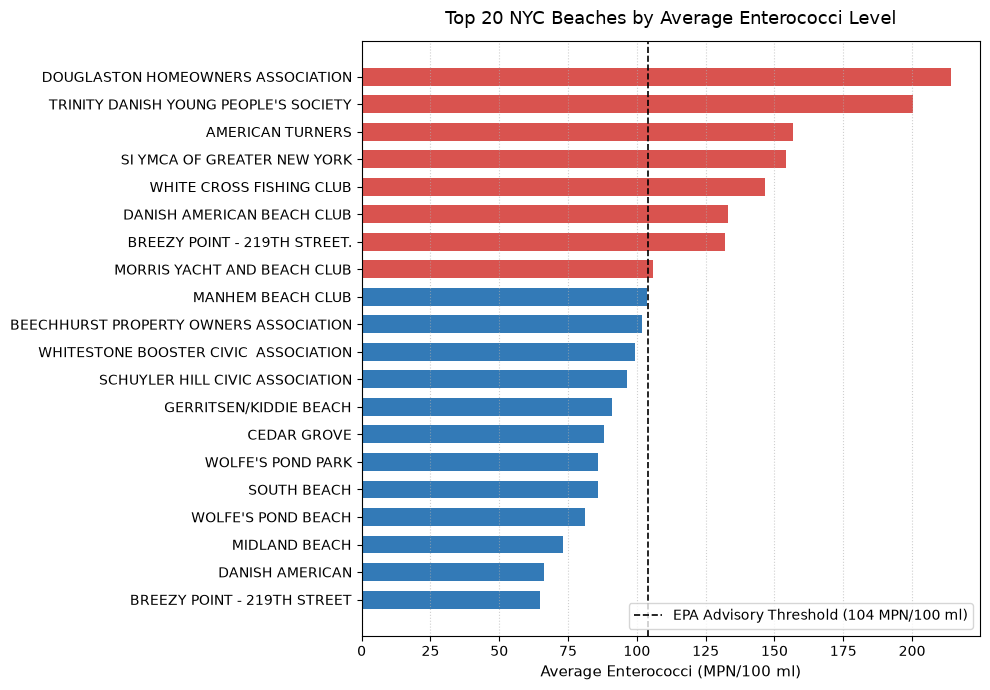

In [12]:
# Compute top 20 beaches
top_20 = (
    df.groupby("beach_name")["enterococci"]
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)

# Set colors: Red if > 104, Teal/Blue if compliant
colors = ["#d9534f" if val > 104 else "#337ab7" for val in top_20.values]

plt.figure(figsize=(10, 7))
bars = plt.barh(top_20.index, top_20.values, color=colors, height=0.65)

# Reference advisory line
plt.axvline(
    x=104,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="EPA Advisory Threshold (104 MPN/100 ml)",
)

plt.title("Top 20 NYC Beaches by Average Enterococci Level", fontsize=13, pad=12)
plt.xlabel("Average Enterococci (MPN/100 ml)", fontsize=11)
plt.ylabel("")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

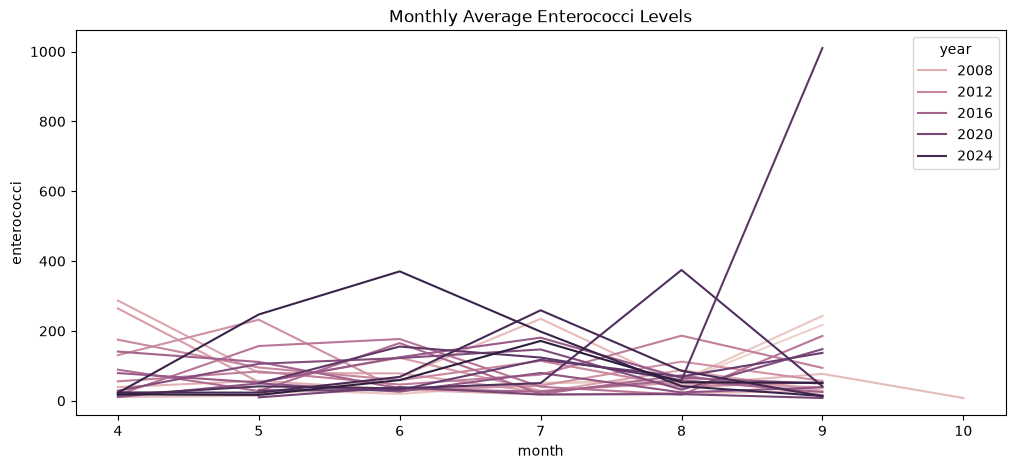

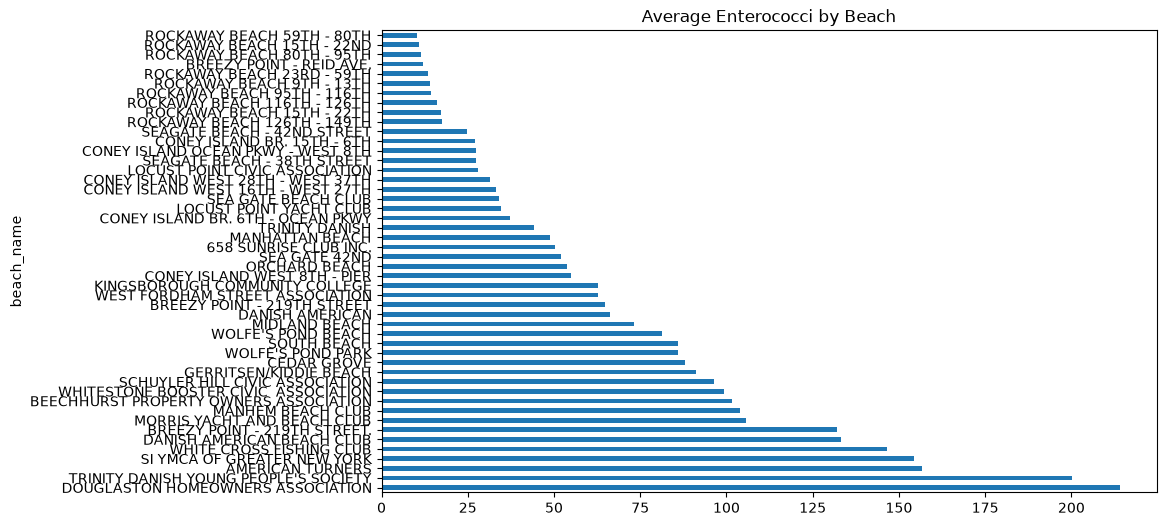

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly trend
monthly = df.groupby(['year', 'month'])['enterococci'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='month', y='enterococci', hue='year')
plt.title('Monthly Average Enterococci Levels')
plt.show()


In [22]:
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="NYC Beach Safety Monitor", layout="wide")
st.title("NYC Water Quality & Beach Safety Monitor")

# Sidebar
beach = st.sidebar.selectbox("Select Beach", df['beach_name'].unique())
date_range = st.sidebar.date_input("Date Range", [df['sample_date'].min(), df['sample_date'].max()])

# Filter
filtered = df[(df['beach_name'] == beach) & 
              (df['sample_date'] >= pd.Timestamp(date_range[0])) & 
              (df['sample_date'] <= pd.Timestamp(date_range[1]))]

# KPI
col1, col2, col3 = st.columns(3)
col1.metric("Avg Enterococci", f"{filtered['enterococci'].mean():.1f} MPN/100mL")
col2.metric("Advisories", filtered['advisory'].sum())
col3.metric("Samples", len(filtered))

# Charts
fig = px.line(filtered, x='sample_date', y='enterococci', title=f'Enterococci Trend - {beach}')
st.plotly_chart(fig, use_container_width=True)

fig2 = px.bar(df.groupby('beach_name')['enterococci'].mean().reset_index(), 
              x='beach_name', y='enterococci', title='Average by Beach')
st.plotly_chart(fig2, use_container_width=True)

2026-09-17 00:19:01.619 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-17 00:19:01.621 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-17 00:19:01.859 
  command:

    streamlit run C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-17 00:19:01.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-17 00:19:01.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-17 00:19:01.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-17 00:19:01.868 Thread 'MainThread': missing ScriptRunContext! This warning can be

DeltaGenerator()